# Violações às Hipóteses do Modelo de Regressão Linear

O [notebook anterior](regressao_multipla.ipynb) listou os pressupostos de Gauss-Markov e
testou dois deles de passagem (multicolinearidade via VIF, heterocedasticidade via
Breusch-Pagan). Este notebook aprofunda **cada hipótese**, mostra como ela se quebra na
prática, e fecha com um estudo de caso real que expõe o tipo de violação que motiva
modelos mais avançados (como o GARCH do [Módulo 09](../09_Séries_Temporais)).

Pré-requisito: [regressao_multipla.ipynb](regressao_multipla.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import (
    linear_reset, acorr_breusch_godfrey, het_arch, het_breuschpagan, acorr_ljungbox
)
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
import yfinance as yf

plt.rcParams.update({'font.size': 12})
rng = np.random.default_rng(42)

## 1. Linearidade nos parâmetros

A primeira hipótese exige que o modelo seja linear **nos parâmetros** $\beta$ — não
necessariamente nas variáveis. $Y = \beta_0 + \beta_1 X^2 + u$ é linear no parâmetro
(pode ser estimado por MQO tratando $X^2$ como uma variável qualquer); já
$Y = \beta_0 + X^{\beta_1} + u$ não é — $\beta_1$ aparece dentro de um expoente, e o MQO
comum não serve.

Essa distinção é o que permite ao mesmo MQO estimar retas, parábolas, funções log-log
(como a Cobb-Douglas do notebook anterior) e polinômios — todos lineares nos
parâmetros, mesmo descrevendo relações bem não-lineares entre $X$ e $Y$.

## 2. Exogeneidade e viés de variável omitida

$E(u|X) = 0$ exige que o erro não carregue informação sistemática relacionada a $X$. A
violação mais comum: **omitir uma variável relevante que é correlacionada com uma
variável incluída** — o efeito da variável omitida "vaza" para dentro do coeficiente
estimado da variável incluída, viesando-o.

### Demonstração — simulação com efeito verdadeiro conhecido

Construímos dados onde sabemos o verdadeiro efeito de $X_1$ sobre $Y$ (porque nós mesmos
geramos os dados) e comparamos o que acontece estimando o modelo certo x um modelo que
omite $X_2$ (correlacionado com $X_1$).

In [2]:
n = 500
x1 = rng.normal(10, 3, n)
x2 = 0.6 * x1 + rng.normal(0, 2, n)  # x2 correlacionado com x1
u = rng.normal(0, 3, n)

beta0_real, beta1_real, beta2_real = 2, 3, 5
y = beta0_real + beta1_real * x1 + beta2_real * x2 + u

modelo_omitido = sm.OLS(y, sm.add_constant(x1)).fit()
modelo_correto = sm.OLS(y, sm.add_constant(np.column_stack([x1, x2]))).fit()

print(f"Efeito verdadeiro de X1 (por construção): {beta1_real}")
print(f"Coeficiente de X1 -- modelo que OMITE X2:    {modelo_omitido.params[1]:.4f}  (viesado)")
print(f"Coeficiente de X1 -- modelo correto (c/ X2):  {modelo_correto.params[1]:.4f}  (próximo do real)")

Efeito verdadeiro de X1 (por construção): 3
Coeficiente de X1 -- modelo que OMITE X2:    6.0240  (viesado)
Coeficiente de X1 -- modelo correto (c/ X2):  3.0879  (próximo do real)


O coeficiente de $X_1$ quase **dobra** quando $X_2$ é omitido — não porque o efeito
de $X_1$ mudou, mas porque parte do efeito de $X_2$ (que é correlacionado com $X_1$) foi
incorretamente atribuída a ele. Na prática, nunca temos certeza de ter incluído todas as
variáveis relevantes — por isso a fundamentação teórica do modelo (qual a teoria
econômica por trás da escolha de variáveis) importa tanto quanto a estatística.

## 3. Especificação correta da forma funcional

Mesmo incluindo as variáveis certas, usar a forma funcional errada (ex: uma relação
quadrática tratada como linear) também viola a hipótese de especificação correta. O
**teste RESET de Ramsey** testa isso de forma genérica: adiciona potências dos valores
previstos ($\hat{y}^2$, $\hat{y}^3$) ao modelo e verifica se elas ajudam a explicar $Y$
— se ajudarem, é sinal de que falta capturar alguma não-linearidade.

In [3]:
# Um caso onde a forma funcional verdadeira é quadrática
x = rng.uniform(0, 10, n)
y_quad = 5 + 2*x - 0.3*x**2 + rng.normal(0, 2, n)

modelo_linear = sm.OLS(y_quad, sm.add_constant(x)).fit()
reset = linear_reset(modelo_linear, power=3, use_f=True)

print(f"Teste RESET (modelo linear ajustado a uma relação quadrática):")
print(f"  estatística F = {reset.fvalue:.4f}   p-valor = {reset.pvalue:.6f}")
print("  p-valor baixo: o RESET corretamente sinaliza que falta uma forma funcional")
print("  não-linear (o modelo devia incluir x²).")

Teste RESET (modelo linear ajustado a uma relação quadrática):
  estatística F = 293.5216   p-valor = 0.000000
  p-valor baixo: o RESET corretamente sinaliza que falta uma forma funcional
  não-linear (o modelo devia incluir x²).


## 4. Multicolinearidade

Já visto no notebook anterior via VIF. Uma multicolinearidade **quase perfeita** (não
apenas moderada) infla demais os erros-padrão dos coeficientes, tornando-os
estatisticamente não-significativos mesmo quando o modelo como um todo é útil.

In [4]:
x_a = rng.normal(0, 1, n)
x_b = x_a + rng.normal(0, 0.01, n)  # quase idêntica a x_a -- colinearidade quase perfeita
y_colinear = 3 + 2*x_a + 2*x_b + rng.normal(0, 1, n)

X_colinear = sm.add_constant(np.column_stack([x_a, x_b]))
modelo_colinear = sm.OLS(y_colinear, X_colinear).fit()

print(modelo_colinear.summary().tables[1])
vifs = [variance_inflation_factor(X_colinear, i) for i in range(X_colinear.shape[1])]
print(f"\nVIF de x_a e x_b: {vifs[1]:.1f}, {vifs[2]:.1f} (extremamente alto)")
print("Os erros-padrão ficam enormes e os coeficientes individuais perdem significância --")
print("mesmo x_a e x_b, juntas, claramente explicando y (o modelo não consegue separar")
print("o efeito de uma da outra, porque na amostra elas quase não variam de forma independente).")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9815      0.044     67.575      0.000       2.895       3.068
x1             4.6407      4.534      1.024      0.307      -4.267      13.548
x2            -0.5616      4.532     -0.124      0.901      -9.467       8.343

VIF de x_a e x_b: 10937.3, 10937.3 (extremamente alto)
Os erros-padrão ficam enormes e os coeficientes individuais perdem significância --
mesmo x_a e x_b, juntas, claramente explicando y (o modelo não consegue separar
o efeito de uma da outra, porque na amostra elas quase não variam de forma independente).


## 5. Homocedasticidade -- estudo de caso real

A hipótese de homocedasticidade exige que a variância do erro seja constante. Em dados
**financeiros**, essa hipótese quase sempre falha de um jeito específico: períodos de
alta volatilidade tendem a vir seguidos de mais alta volatilidade (*volatility
clustering*) -- os erros não têm variância constante, mas sim uma variância que **depende
do próprio passado**. Isso é heterocedasticidade **condicional**, e é exatamente o que os
modelos da família ARCH/GARCH foram desenhados para modelar.

Vamos regredir os retornos diários do Ibovespa contra os do S&P 500 (dados reais, ao
vivo) com MQO simples -- o jeito "ingênuo" de analisar essa relação -- e testar se os
resíduos violam homocedasticidade.

In [5]:
precos = yf.download(['^BVSP', '^GSPC'], start='2015-01-01', progress=False, auto_adjust=True)['Close']
precos = precos.dropna()

retornos = np.log(precos).diff().dropna() * 100
retornos.columns = ['ibovespa', 'sp500']

print(f"{len(retornos)} observações diárias, de {retornos.index.min():%Y-%m-%d} a {retornos.index.max():%Y-%m-%d}")
retornos.tail()

2802 observações diárias, de 2015-01-05 a 2026-08-05


,ibovespa,sp500
Date,,
2026-07-30,1.865347,1.646801
2026-07-31,0.473030,0.697921
2026-08-03,0.000562,1.468259
2026-08-04,-0.059006,1.773794
2026-08-05,-0.095045,-0.167790


In [6]:
X_fin = sm.add_constant(retornos['sp500'])
y_fin = retornos['ibovespa']

modelo_ingenuo = sm.OLS(y_fin, X_fin).fit()
print(modelo_ingenuo.summary())

                            OLS Regression Results                            
Dep. Variable:               ibovespa   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     1244.
Date:                Thu, 06 Aug 2026   Prob (F-statistic):          7.83e-226
Time:                        03:20:48   Log-Likelihood:                -4555.2
No. Observations:                2802   AIC:                             9114.
Df Residuals:                    2800   BIC:                             9126.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0122      0.023      0.525      0.5

O `summary()` já mostra um Jarque-Bera altíssimo (resíduos longe de normais -- caudas
pesadas, típico de retornos financeiros) e um Durbin-Watson próximo de 2 (sem
autocorrelação **linear** simples nos resíduos). Mas isso não significa que o modelo está
bem especificado -- o problema mora na **variância condicional**, que o Durbin-Watson não
enxerga.

In [7]:
# Teste ARCH-LM (Engle): testa autocorrelação nos resíduos AO QUADRADO --
# exatamente o sintoma de heterocedasticidade condicional (ARCH)
arch_lm_stat, arch_lm_pvalue, _, _ = het_arch(modelo_ingenuo.resid, nlags=5)
print(f"ARCH-LM: estatística = {arch_lm_stat:.2f}   p-valor = {arch_lm_pvalue:.2e}")

# Confirmação via Ljung-Box sobre os resíduos ao quadrado
lb_quadrado = acorr_ljungbox(modelo_ingenuo.resid ** 2, lags=[5], return_df=True)
print(f"\nLjung-Box nos resíduos²: estatística = {lb_quadrado['lb_stat'].iloc[0]:.2f}   "
      f"p-valor = {lb_quadrado['lb_pvalue'].iloc[0]:.2e}")

print("\nOs dois testes rejeitam homocedasticidade com folga (p-valor essencialmente zero).")
print("Há heterocedasticidade condicional real nos dados -- exatamente o motivo pelo qual")
print("análises sérias de volatilidade de mercado usam GARCH em vez de MQO simples.")

ARCH-LM: estatística = 319.81   p-valor = 5.49e-67

Ljung-Box nos resíduos²: estatística = 577.34   p-valor = 1.59e-122

Os dois testes rejeitam homocedasticidade com folga (p-valor essencialmente zero).
Há heterocedasticidade condicional real nos dados -- exatamente o motivo pelo qual
análises sérias de volatilidade de mercado usam GARCH em vez de MQO simples.


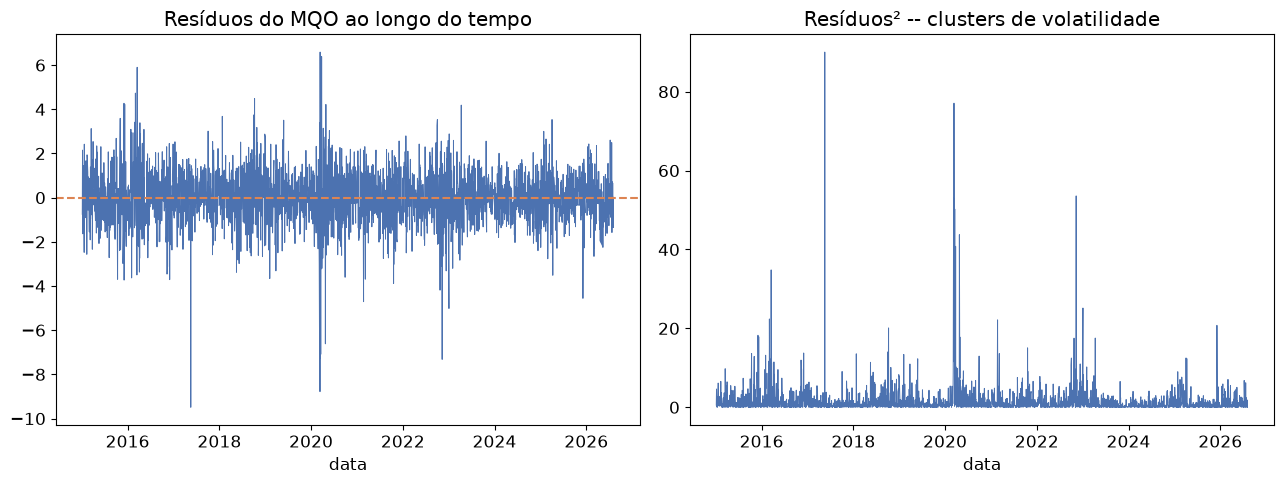

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(modelo_ingenuo.resid, color='#4C72B0', linewidth=0.7)
axes[0].axhline(0, color='#DD8452', linestyle='--')
axes[0].set_title('Resíduos do MQO ao longo do tempo')
axes[0].set_xlabel('data')

axes[1].plot(modelo_ingenuo.resid ** 2, color='#4C72B0', linewidth=0.7)
axes[1].set_title('Resíduos² -- clusters de volatilidade')
axes[1].set_xlabel('data')

plt.tight_layout()
plt.savefig('img_volatility_clustering.png', dpi=110)
plt.show()

Reparem no painel da direita: os períodos de resíduo² alto vêm em **blocos**, não
espalhados aleatoriamente -- a marca visual clássica de volatility clustering. É esse
padrão que o teste ARCH-LM está formalizando, e é exatamente esse tipo de violação que
motivou a virada de um modelo de médias simples (MQO/ARIMA) para um modelo GARCH em
projetos reais de volatilidade de mercado.

## 6. Autocorrelação

Quando o erro de uma observação é correlacionado com o erro de outra (comum em séries
temporais), o MQO continua não-viesado, mas deixa de ser o estimador de menor variância
-- e os erros-padrão relatados ficam incorretos (tipicamente subestimados), inflando
artificialmente a significância dos coeficientes. O teste de **Breusch-Godfrey**
generaliza o Durbin-Watson para múltiplas defasagens.

In [9]:
# Construindo uma série com autocorrelação proposital nos erros
n_ts = 300
x_ts = rng.normal(0, 1, n_ts)
erro_autocorrelacionado = np.zeros(n_ts)
for t in range(1, n_ts):
    erro_autocorrelacionado[t] = 0.7 * erro_autocorrelacionado[t-1] + rng.normal(0, 1)

y_ts = 4 + 1.5 * x_ts + erro_autocorrelacionado

modelo_ts = sm.OLS(y_ts, sm.add_constant(x_ts)).fit()
bg_stat, bg_pvalue, _, _ = acorr_breusch_godfrey(modelo_ts, nlags=4)

print(f"Durbin-Watson: {sm.stats.durbin_watson(modelo_ts.resid):.4f}  (bem abaixo de 2 -- alerta)")
print(f"Breusch-Godfrey: estatística={bg_stat:.4f}  p-valor={bg_pvalue:.6f}")
print("\np-valor baixo confirma autocorrelação nos resíduos -- coerente com o jeito")
print("que construímos o erro (dependente do próprio valor no período anterior).")

Durbin-Watson: 0.7811  (bem abaixo de 2 -- alerta)
Breusch-Godfrey: estatística=112.5165  p-valor=0.000000

p-valor baixo confirma autocorrelação nos resíduos -- coerente com o jeito
que construímos o erro (dependente do próprio valor no período anterior).


## 7. Normalidade dos erros

Necessária não para o MQO ser não-viesado, mas para que os testes t e F sejam
**exatos** em amostras pequenas (em amostras grandes, o Teorema Central do Limite do
[Módulo 04](../04_Inferência_Estatística) socorre mesmo sem normalidade). O teste de
**Jarque-Bera** usa assimetria e curtose dos resíduos para testar normalidade.

In [10]:
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(modelo_ingenuo.resid)
print(f"Jarque-Bera (resíduos do modelo Ibovespa x S&P500): estatística={jb_stat:.1f}  p-valor={jb_pvalue:.2e}")
print(f"Assimetria = {skew:.3f}   Curtose = {kurtosis:.3f}  (Normal teria assimetria=0, curtose=3)")
print("\nCurtose bem acima de 3: caudas mais pesadas que a Normal -- outra marca registrada")
print("de retornos financeiros (eventos extremos são mais frequentes do que a Normal preveria).")

Jarque-Bera (resíduos do modelo Ibovespa x S&P500): estatística=2775.6  p-valor=0.00e+00
Assimetria = -0.475   Curtose = 7.782  (Normal teria assimetria=0, curtose=3)

Curtose bem acima de 3: caudas mais pesadas que a Normal -- outra marca registrada
de retornos financeiros (eventos extremos são mais frequentes do que a Normal preveria).


## 8. O que fazer diante de uma violação

Resumo prático -- nenhuma violação aqui é motivo para descartar o MQO por completo, mas
cada uma pede um ajuste diferente:

| Violação | Sintoma | Contorno comum |
|---|---|---|
| Variável omitida | Coeficientes implausíveis, mudam muito ao adicionar controles | Fundamentar o modelo em teoria, testar robustez a controles adicionais |
| Forma funcional errada | RESET significativo | Termos polinomiais, transformação log |
| Multicolinearidade forte | VIF alto, coeficientes instáveis | Remover/combinar variáveis redundantes, mais dados |
| Heterocedasticidade | Breusch-Pagan/ARCH-LM significativo | Erros-padrão robustos (HC3), ou modelar a variância diretamente (GARCH) |
| Autocorrelação | Durbin-Watson longe de 2, Breusch-Godfrey significativo | Erros-padrão HAC (Newey-West), modelos ARIMA |
| Não-normalidade | Jarque-Bera significativo | Amostras grandes (TCL ajuda), bootstrap para inferência |

## 9. Exercícios de fixação

1. Gere `y = 3 + 2*x + 0.05*x**3 + erro` para `x` entre 0 e 10, ajuste um modelo linear
   simples e rode o teste RESET. O que ele indica?
2. Usando o modelo Ibovespa x S&P 500 já ajustado (`modelo_ingenuo`), rode o teste de
   Breusch-Pagan (não o ARCH-LM) sobre os resíduos. Ele também rejeita homocedasticidade?

In [11]:
# 1.
x_ex = rng.uniform(0, 10, 300)
y_ex = 3 + 2*x_ex + 0.05*x_ex**3 + rng.normal(0, 2, 300)
modelo_ex = sm.OLS(y_ex, sm.add_constant(x_ex)).fit()
reset_ex = linear_reset(modelo_ex, power=3, use_f=True)
print(f"1) RESET: F={reset_ex.fvalue:.2f}  p-valor={reset_ex.pvalue:.6f}")
print("   p-valor baixo -> forma funcional linear não é adequada (falta o termo cúbico).")

# 2.
bp_stat, bp_pvalue, _, _ = het_breuschpagan(modelo_ingenuo.resid, X_fin)
veredito = "rejeita" if bp_pvalue < 0.05 else "não rejeita"
print(f"\n2) Breusch-Pagan: estatística={bp_stat:.2f}  p-valor={bp_pvalue:.4f}  ({veredito} homocedasticidade)")
print("   Os dois testes concordam aqui, mas testam coisas diferentes: ARCH-LM testa")
print("   dependência temporal na variância (o resíduo de hoje prevê a variância de amanhã),")
print("   enquanto Breusch-Pagan testa se a variância depende do NÍVEL de X -- podem")
print("   divergir em outros contextos, por isso vale rodar os dois.")

1) RESET: F=975.70  p-valor=0.000000
   p-valor baixo -> forma funcional linear não é adequada (falta o termo cúbico).

2) Breusch-Pagan: estatística=19.80  p-valor=0.0000  (rejeita homocedasticidade)
   Os dois testes concordam aqui, mas testam coisas diferentes: ARCH-LM testa
   dependência temporal na variância (o resíduo de hoje prevê a variância de amanhã),
   enquanto Breusch-Pagan testa se a variância depende do NÍVEL de X -- podem
   divergir em outros contextos, por isso vale rodar os dois.


## Encerramento

Este notebook fecha o Módulo 07 com uma visão mais realista da regressão múltipla: nem
todo modelo estimado satisfaz todas as hipóteses de Gauss-Markov de primeira, e parte do
trabalho de um analista é diagnosticar isso -- não para descartar o modelo, mas para
saber exatamente que tipo de correção ou modelo mais sofisticado (como o GARCH do
[Módulo 09](../09_Séries_Temporais)) o problema pede.

## Bibliografia
- WOOLDRIDGE, Jeffrey M. *Introdução à Econometria: uma abordagem moderna*. São Paulo: Cengage Learning, 2016.
- GUJARATI, Damodar N.; PORTER, Dawn C. *Econometria Básica*. 5. ed. Porto Alegre: AMGH, 2011.
- ENGLE, Robert F. (1982). "Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation". *Econometrica*, 50(4).
- RAMSEY, J. B. (1969). "Tests for Specification Errors in Classical Linear Least-Squares Regression Analysis". *Journal of the Royal Statistical Society*, Series B.